# 04 · Image-level classifier

**Goal:** a classifier that separates pneumonia images from the rest as well as possible. It gives every image a pneumonia score; in 06 this score decides which images get boxes from the detector.

**Questions this notebook answers**
1. **2 or 3 classes?** Is it better to train on pneumonia vs rest, or on the 3 original classes (Normal / Not Normal / Lung Opacity)? (section 2)
2. **Which backbone?** How do 7 backbones common in chest X-ray work rank on this data? (section 3)
3. **Does an ensemble help?** Which way of combining the models, how many models, and do view, sex and age add anything? (section 5)
4. **Does a higher resolution help?** 256 vs 384 vs 512 pixels. (sections 6–7)
5. **Do copies of the same model help?** A deep ensemble (5 seeds) and bagging (5 bootstrap models) of ConvNeXt-Tiny, and how much the score moves with the seed alone. (section 8)

Section 9 sums up the answers and the classifier chosen for 06.

Needs `patients.csv` and `test.csv` from `scripts/prepare_data.py`, the downscaled images from `scripts/resize_images.py`, and the training runs in `outputs/classification/` from `scripts/train_classifier.py`.

In [1]:
import json
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.special import logit
from scipy.stats import rankdata
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score, roc_curve

from rsna.paths import load_paths

pd.set_option("display.width", 220)
pd.set_option("display.float_format", "{:.4f}".format)

paths = load_paths()
CLS_DIR = paths["outputs_dir"] / "classification"
patients = pd.read_csv(paths["processed_data_dir"] / "patients.csv")
test = pd.read_csv(paths["processed_data_dir"] / "test.csv")
y = (patients["class"] == "Lung Opacity").to_numpy()
fold = patients["fold"].to_numpy()

MODELS = ["convnext_tiny", "mobilevitv2_150", "densenet121", "tf_efficientnetv2_s", "seresnext50_32x4d",
          "efficientnet_b4", "efficientnet_b2"]
TOP4 = MODELS[:4]
NAMES = {"convnext_tiny": "ConvNeXt-Tiny", "mobilevitv2_150": "MobileViTv2-1.5", "densenet121": "DenseNet-121",
         "tf_efficientnetv2_s": "EfficientNetV2-S", "seresnext50_32x4d": "SE-ResNeXt50", "efficientnet_b4": "EfficientNet-B4",
         "efficientnet_b2": "EfficientNet-B2"}


def run_path(size, model, k):
    return CLS_DIR / f"main_{size}" / f"{model}_3c_f{k}_s0"


def summary(size, model, k):
    return json.loads((run_path(size, model, k) / "summary.json").read_text())


def config(size, model, k=0):
    return json.loads((run_path(size, model, k) / "config.json").read_text())


def oof(size, model):
    """TTA pneumonia score of every training image from the fold model that did not train on it (patients.csv order)."""
    preds = pd.concat([pd.read_csv(run_path(size, model, k) / "val_preds_tta.csv") for k in range(5)])
    return preds.set_index("patient_id").loc[patients["patient_id"], "p_pneumonia"].to_numpy()


def test_scores(size, model):
    """TTA pneumonia scores of the 5 fold models on the test images, shape (5, images) in test.csv order."""
    return np.stack([pd.read_csv(run_path(size, model, k) / "test_preds_tta.csv").set_index("patient_id")
                    .loc[test["patient_id"], "p_pneumonia"] for k in range(5)])


def oof_row(score, probability=True):
    """OOF AUC, mean and std of the 5 fold AUCs, and F1 at 0.5 (not for rank scores)."""
    per_fold = [roc_auc_score(y[fold == k], score[fold == k]) for k in range(5)]
    return {"OOF AUC": roc_auc_score(y, score), "fold AUC, mean": np.mean(per_fold), "fold AUC, std": np.std(per_fold),
            "F1": f1_score(y, score >= 0.5) if probability else np.nan}


def paired_bootstrap(target, a, b, n=2000, seed=0):
    """AUC(a) - AUC(b) and its 95% interval over n resamples of the same images."""
    rng = np.random.default_rng(seed)
    diffs = []
    for _ in range(n):
        i = rng.integers(0, len(target), len(target))
        diffs.append(roc_auc_score(target[i], a[i]) - roc_auc_score(target[i], b[i]))
    low, high = np.percentile(diffs, [2.5, 97.5])
    return {"AUC difference": roc_auc_score(target, a) - roc_auc_score(target, b), "95% interval": f"[{low:.4f}, {high:.4f}]"}


def bootstrap_table(target, scores, comparisons):
    """One row per (a, b) pair: AUC(a) - AUC(b) with its interval."""
    return pd.DataFrame({f"{a} − {b}": paired_bootstrap(target, scores[a], scores[b]) for a, b in comparisons}).T


print(len(patients), "training images,", len(test), "test images,", f"{y.mean():.1%} Lung Opacity")

26684 training images, 3000 test images, 22.5% Lung Opacity


## 1. Setup

- **Data:** the 26,684 training images and the 5 patient folds from 02, downscaled from the 1024 cache with area averaging (`scripts/resize_images.py`). The whole array sits on the GPU as uint8.
- **Model:** an ImageNet-pretrained timm backbone with 1 input channel and 3 outputs (Normal / Not Normal / Lung Opacity, softmax). The pneumonia score is p(Lung Opacity).
- **Training** (`scripts/train_classifier.py`): AdamW (weight decay 0.05), lr = 3e-4 × √(batch / 256) with 50 warm-up steps, halved after 3 epochs without a better validation AUC, early stop after 5, at most 20 epochs. Label smoothing 0.1, drop path 0.1, bf16.
- **Batch size:** the largest one that keeps the GPU under 80% of its memory, found with short probe runs.
- **Augmentation** on the GPU: horizontal and vertical flip, rotation ±13°, scale 0.85–1.15, shift ±8%, brightness and contrast ±15%. The vertical flip and CLAHE are checked in 7.2.
- **Evaluation:** each run keeps the epoch with the best validation AUC. F1 uses the threshold 0.5.
- **TTA (test-time augmentation):** at prediction time the model also sees the horizontally flipped copy of each image, and the two scores are averaged. This costs one extra forward pass and usually gives a slightly more stable score. Results are reported with and without it; everything from section 5 on uses the TTA scores.
- **OOF:** every training image scored by the fold model that did not train on it; 26,684 scores per model.
- **AUC** is always pneumonia (Lung Opacity) vs the other two classes.

## 2. 2 classes vs 3 classes

Fold 0, 256 × 256, MobileViTv2-1.0 / DenseNet-121 / EfficientNet-B0, 2 seeds each. The 2-class model has one sigmoid output (pneumonia or not). This first experiment used slightly different training: lr 5e-4 with a cosine schedule over 20 epochs, lighter augmentation, no label smoothing, drop path or early stopping.

Mean AUC and F1 of the 2 seeds:

In [2]:
exp23 = CLS_DIR / "fold0_256"
runs23 = sorted(p for p in exp23.iterdir() if (p / "summary.json").exists())
configs23 = [json.loads((p / "config.json").read_text()) for p in runs23]
RUNS23 = {(c["model"].split(".")[0], c["n_classes"], c["seed"]): p for c, p in zip(configs23, runs23)}
NAMES23 = {"mobilevitv2_100": "MobileViTv2-1.0", "densenet121": "DenseNet-121", "efficientnet_b0": "EfficientNet-B0"}
s23 = pd.DataFrame([json.loads((p / "summary.json").read_text()) for p in runs23])
s23["model"] = [NAMES23[c["model"].split(".")[0]] for c in configs23]
s23["classes"] = [f"{c['n_classes']} classes" for c in configs23]
s23.groupby(["model", "classes"])[["auc", "f1"]].mean().rename(columns={"auc": "AUC", "f1": "F1"})

AUC     F1
model           classes                
DenseNet-121    2 classes 0.8870 0.5903
                3 classes 0.8925 0.5982
EfficientNet-B0 2 classes 0.8788 0.5784
                3 classes 0.8760 0.5602
MobileViTv2-1.0 2 classes 0.8887 0.5820
                3 classes 0.8913 0.5234

Is the difference larger than chance? Paired bootstrap on the 5,337 validation images: AUC with 3 classes − AUC with 2 classes, each setting's 2 seeds averaged.

In [3]:
rows = {}
for model, name in NAMES23.items():
    preds = {nc: [pd.read_csv(RUNS23[model, nc, s] / "val_preds.csv") for s in (0, 1)] for nc in (2, 3)}
    target = preds[2][0]["class"].to_numpy() == 2
    p = {nc: np.mean([d["p_pneumonia"] for d in preds[nc]], axis=0) for nc in preds}
    rows[name] = paired_bootstrap(target, p[3], p[2])
pd.DataFrame(rows).T.rename(columns={"AUC difference": "AUC difference (3 − 2 classes)"})

,AUC difference (3 − 2 classes),95% interval
MobileViTv2-1.0,0.0015,"[-0.0018, 0.0048]"
DenseNet-121,0.0057,"[0.0018, 0.0096]"
EfficientNet-B0,-0.0005,"[-0.0049, 0.0038]"


**Result**
- DenseNet-121: 3 classes are better by 0.006 AUC (95% interval 0.002 to 0.010).
- MobileViTv2: +0.002, EfficientNet-B0: −0.001; both intervals include 0.
- **Choice: 3 classes.** They are clearly better for DenseNet-121, and for the other two backbones the difference is too small to tell from chance.

## 3. Main training: 7 models × 5 folds at 256 × 256

- **Fold mean:** the AUC (or F1) on each fold's 5,337 validation images, averaged over the 5 folds; with and without TTA.
- **OOF:** one AUC (or F1) over all 26,684 images at once, each scored by the fold model that did not train on it; with TTA.
- **Positive rate:** the share of images scored above 0.5; the true share of pneumonia is 22.5%.

In [4]:
rows = {}
for m in MODELS:
    s = pd.DataFrame([summary(256, m, k) for k in range(5)])
    score = oof(256, m)
    rows[NAMES[m]] = {("", "timm model"): config(256, m)["model"],
                      ("fold mean", "AUC"): s.auc.mean(), ("fold mean", "AUC + TTA"): s.auc_tta.mean(),
                      ("fold mean", "F1"): s.f1.mean(), ("fold mean", "F1 + TTA"): s.f1_tta.mean(),
                      ("OOF, TTA", "AUC"): roc_auc_score(y, score), ("OOF, TTA", "F1"): f1_score(y, score >= 0.5),
                      ("OOF, TTA", "positive rate at 0.5"): (score >= 0.5).mean()}
pd.DataFrame(rows).T

fold mean                           OOF, TTA                            
                                            timm model       AUC AUC + TTA     F1 F1 + TTA      AUC     F1 positive rate at 0.5
ConvNeXt-Tiny           convnext_tiny.fb_in22k_ft_in1k    0.8981    0.8991 0.6411   0.6381   0.8976 0.6399               0.1860
MobileViTv2-1.5   mobilevitv2_150.cvnets_in22k_ft_in1k    0.8973    0.8991 0.6306   0.6311   0.8952 0.6355               0.1797
DenseNet-121                       densenet121.tv_in1k    0.8920    0.8944 0.6303   0.6311   0.8920 0.6316               0.1760
EfficientNetV2-S     tf_efficientnetv2_s.in21k_ft_in1k    0.8906    0.8919 0.6096   0.6081   0.8900 0.6105               0.1608
SE-ResNeXt50               seresnext50_32x4d.racm_in1k    0.8932    0.8944 0.6113   0.6103   0.8895 0.6161               0.1695
EfficientNet-B4               efficientnet_b4.ra2_in1k    0.8840    0.8871 0.6092   0.6117   0.8859 0.6129               0.1710
EfficientNet-B2                efficientnet_b2.ra_in1k    0.8856    0.8878 0.5792   0.5788   0.8856 0.5828               0.1451

**Result**
- ConvNeXt-Tiny and MobileViTv2-1.5 are the best single models: OOF AUC 0.898 / 0.895, F1 0.640 / 0.636. EfficientNet-B2 is last (0.886, F1 0.583).
- TTA raises the fold-mean AUC of every model a little, by 0.001–0.003.
- At 0.5 every model predicts fewer positives (14.5–18.6%) than there are (22.5%). The threshold is chosen in 06.

## 4. A larger model: ConvNeXt V2-Base (fold 0 only)

This question was not part of the original plan. Section 3 showed that the best model is ConvNeXt-Tiny, one of the smallest members of the ConvNeXt family. So we asked: would a larger model from the same family do better?

We tried ConvNeXt V2-Base: 89M parameters vs 28M for ConvNeXt-Tiny, pretrained on ImageNet-22k. Same training, with a 30-epoch limit. It was trained on fold 0 first; the other 4 folds would be trained only if it were clearly better than ConvNeXt-Tiny there.

In [5]:
v2 = CLS_DIR / "main_256" / "convnextv2_base_3c_f0_s0"
cols = {"auc": "AUC", "f1": "F1", "auc_tta": "AUC + TTA", "f1_tta": "F1 + TTA", "minutes": "minutes"}
pd.DataFrame([{name: summary(256, "convnext_tiny", 0)[c] for c, name in cols.items()},
              {name: json.loads((v2 / "summary.json").read_text())[c] for c, name in cols.items()}],
             index=["ConvNeXt-Tiny", "ConvNeXt V2-Base"])

,AUC,F1,AUC + TTA,F1 + TTA,minutes
ConvNeXt-Tiny,0.9001,0.6446,0.9011,0.6367,3.8484
ConvNeXt V2-Base,0.8989,0.6364,0.8995,0.6523,15.0569


Paired bootstrap on the 5,337 fold-0 images:

In [6]:
rows = {}
for suffix, label in [("", "without TTA"), ("_tta", "with TTA")]:
    tiny = pd.read_csv(run_path(256, "convnext_tiny", 0) / f"val_preds{suffix}.csv")
    base = pd.read_csv(v2 / f"val_preds{suffix}.csv")
    assert (tiny["patient_id"] == base["patient_id"]).all()
    rows[label] = paired_bootstrap(tiny["class"].to_numpy() == 2, base["p_pneumonia"].to_numpy(),
                                   tiny["p_pneumonia"].to_numpy())
pd.DataFrame(rows).T.rename(columns={"AUC difference": "difference (V2-Base − Tiny)"})

,difference (V2-Base − Tiny),95% interval
without TTA,-0.0013,"[-0.0050, 0.0026]"
with TTA,-0.0016,"[-0.0048, 0.0016]"


**Result:** V2-Base is not better than ConvNeXt-Tiny on fold 0 (−0.0016 AUC with TTA, interval −0.005 to +0.002). Its F1 is higher with TTA and lower without it, a threshold effect. It takes 4× longer to train. **The other 4 folds were not trained.**

## 5. Ensembles of the 256 models

All combiners are scored on the OOF predictions. A combiner that learns something is **cross-validated**: the combiner for fold k is fitted on the OOF scores of the other 4 folds and scores only fold k, so no image is scored by a combiner that saw it. (The CNNs behind the other folds' scores were trained on fold k, as usual in stacking.)

- **Plain mean:** the mean of the 7 scores.
- **Rank mean:** the mean of the 7 scores after turning each into ranks. It ignores how each model is calibrated; its values are not probabilities, so it has no F1.
- **Greedy selection:** start from the best model and keep adding the model (repeats allowed) that raises the AUC of the mean the most.
- **Stacking:** a logistic regression on the 7 logits.
- **Stacking + metadata:** the same plus view (AP or PA), sex and age.
- **Metadata only:** view, sex and age alone.

In [7]:
P = np.column_stack([oof(256, m) for m in MODELS])


def to_logit(p):
    return logit(np.clip(p, 1e-6, 1 - 1e-6))


def meta(df):
    return np.column_stack([(df["view"] == "AP").to_numpy(float), (df["sex"] == "M").to_numpy(float),
                            df["age"].clip(upper=100).to_numpy() / 100])


def fit_lr(X, target):
    return LogisticRegression(max_iter=1000).fit(X, target)


def predict_lr(model, X):
    return model.predict_proba(X)[:, 1]


def fit_greedy(X, target, steps=30):
    """Weights of the models chosen with replacement; stops when no model raises the AUC of the mean."""
    counts, best = np.zeros(X.shape[1]), -1.0
    for _ in range(steps):
        scores = [roc_auc_score(target, (X @ counts + X[:, j]) / (counts.sum() + 1)) for j in range(X.shape[1])]
        j = int(np.argmax(scores))
        if scores[j] <= best:
            break
        best, counts[j] = scores[j], counts[j] + 1
    return counts / counts.sum()


def cross_fit(fit, predict, X):
    """OOF score of a fitted combiner: fold k is scored by a combiner fitted on the other folds."""
    score = np.zeros(len(y))
    for k in range(5):
        score[fold == k] = predict(fit(X[fold != k], y[fold != k]), X[fold == k])
    return score


L, M = to_logit(P), meta(patients)
META = ["view = AP", "sex = male", "age / 100"]
ens256 = {"Plain mean": P.mean(1),
          "Rank mean": np.mean([rankdata(c) for c in P.T], axis=0) / len(y),
          "Greedy selection": cross_fit(fit_greedy, lambda w, X: X @ w, P),
          "Stacking": cross_fit(fit_lr, predict_lr, L),
          "Stacking + metadata": cross_fit(fit_lr, predict_lr, np.hstack([L, M])),
          "Metadata only": cross_fit(fit_lr, predict_lr, M)}
scores256 = {NAMES[m]: P[:, i] for i, m in enumerate(MODELS)} | ens256
pd.DataFrame({n: oof_row(s, probability=n != "Rank mean") for n, s in scores256.items()}).T

,OOF AUC,"fold AUC, mean","fold AUC, std",F1
ConvNeXt-Tiny,0.8976,0.8991,0.0014,0.6399
MobileViTv2-1.5,0.8952,0.8991,0.0023,0.6355
DenseNet-121,0.8920,0.8944,0.0030,0.6316
EfficientNetV2-S,0.8900,0.8919,0.0028,0.6105
SE-ResNeXt50,0.8895,0.8944,0.0030,0.6161
EfficientNet-B4,0.8859,0.8871,0.0039,0.6129
EfficientNet-B2,0.8856,0.8878,0.0035,0.5828
Plain mean,0.9013,0.9021,0.0027,0.6285
Rank mean,0.9012,0.9020,0.0026,NaN
Greedy selection,0.9019,0.9029,0.0026,0.6389


Is every ensemble better than the best single model? Paired bootstrap on all 26,684 OOF images:

In [8]:
bootstrap_table(y, scores256, [(n, "ConvNeXt-Tiny") for n in list(ens256)[:5]])

,AUC difference,95% interval
Plain mean − ConvNeXt-Tiny,0.0037,"[0.0025, 0.0050]"
Rank mean − ConvNeXt-Tiny,0.0036,"[0.0023, 0.0049]"
Greedy selection − ConvNeXt-Tiny,0.0043,"[0.0032, 0.0054]"
Stacking − ConvNeXt-Tiny,0.0041,"[0.0031, 0.0051]"
Stacking + metadata − ConvNeXt-Tiny,0.0041,"[0.0030, 0.0051]"


Does metadata help? The same stacking with and without view, sex and age:

In [9]:
bootstrap_table(y, scores256, [("Stacking + metadata", "Stacking")])

,AUC difference,95% interval
Stacking + metadata − Stacking,-0.0001,"[-0.0001, -0.0000]"


Weights fitted on all OOF images (greedy selection: share of picks; stacking: logistic regression coefficients):

In [10]:
weights = pd.DataFrame({"Greedy selection": pd.Series(fit_greedy(P, y), index=MODELS),
                        "Stacking": pd.Series(fit_lr(L, y).coef_[0], index=MODELS),
                        "Stacking + metadata": pd.Series(fit_lr(np.hstack([L, M]), y).coef_[0], index=MODELS + META),
                        "Metadata only": pd.Series(fit_lr(M, y).coef_[0], index=META)})
weights.loc[MODELS + META].rename(index=NAMES)

,Greedy selection,Stacking,Stacking + metadata,Metadata only
ConvNeXt-Tiny,0.3000,0.3903,0.3930,NaN
MobileViTv2-1.5,0.3000,0.3611,0.3610,NaN
DenseNet-121,0.1000,0.1652,0.1633,NaN
EfficientNetV2-S,0.1000,0.1317,0.1309,NaN
SE-ResNeXt50,0.1000,0.0377,0.0379,NaN
EfficientNet-B4,0.1000,0.0912,0.0906,NaN
EfficientNet-B2,0.0000,0.0123,0.0118,NaN
view = AP,NaN,NaN,0.0080,1.7930
sex = male,NaN,NaN,0.0101,0.0536
age / 100,NaN,NaN,0.0159,-0.4417


### 5.1 How many models are needed?

Stacking of every pair of models (with the plain mean of the pair for comparison), and of the 4 best models:

In [11]:
rows = {}
for i, j in combinations(range(len(MODELS)), 2):
    score = cross_fit(fit_lr, predict_lr, L[:, [i, j]])
    rows[(i, j)] = {"pair": f"{NAMES[MODELS[i]]} + {NAMES[MODELS[j]]}", "OOF AUC": roc_auc_score(y, score),
                    "F1": f1_score(y, score >= 0.5), "OOF AUC, plain mean": roc_auc_score(y, P[:, [i, j]].mean(1))}
pairs = pd.DataFrame(rows).T.sort_values("OOF AUC", ascending=False)
pairs.set_index("pair").astype(float)

,OOF AUC,F1,"OOF AUC, plain mean"
pair,,,
ConvNeXt-Tiny + MobileViTv2-1.5,0.9009,0.6430,0.9015
MobileViTv2-1.5 + EfficientNetV2-S,0.8991,0.6447,0.8991
MobileViTv2-1.5 + DenseNet-121,0.8991,0.6430,0.8995
ConvNeXt-Tiny + DenseNet-121,0.8989,0.6395,0.8994
ConvNeXt-Tiny + SE-ResNeXt50,0.8988,0.6380,0.8990
ConvNeXt-Tiny + EfficientNetV2-S,0.8986,0.6405,0.8988
ConvNeXt-Tiny + EfficientNet-B2,0.8983,0.6344,0.8981
ConvNeXt-Tiny + EfficientNet-B4,0.8983,0.6392,0.8978
MobileViTv2-1.5 + EfficientNet-B4,0.8980,0.6419,0.8980


In [12]:
best_pair = list(pairs.index[0])
subsets = {"ConvNeXt-Tiny": P[:, 0], "best pair": cross_fit(fit_lr, predict_lr, L[:, best_pair]),
           "4 best models": cross_fit(fit_lr, predict_lr, L[:, :4]), "all 7 models": ens256["Stacking"]}
display(pd.DataFrame({n: oof_row(s) for n, s in subsets.items()}).T)
bootstrap_table(y, subsets, [("best pair", "ConvNeXt-Tiny"), ("4 best models", "best pair"), ("all 7 models", "4 best models")])

,OOF AUC,"fold AUC, mean","fold AUC, std",F1
ConvNeXt-Tiny,0.8976,0.8991,0.0014,0.6399
best pair,0.9009,0.9026,0.0018,0.6430
4 best models,0.9018,0.9029,0.0021,0.6455
all 7 models,0.9017,0.9030,0.0024,0.6461


,AUC difference,95% interval
best pair − ConvNeXt-Tiny,0.0033,"[0.0023, 0.0042]"
4 best models − best pair,0.0009,"[0.0004, 0.0014]"
all 7 models − 4 best models,-0.0001,"[-0.0003, 0.0001]"


**Result**
- **All ensemble methods are clearly better than the best single model:** +0.0036 to +0.0043 AUC, with intervals well above 0. The methods differ from each other by less than 0.001.
- **Metadata gives no meaningful improvement.** View, sex and age alone reach AUC 0.71 (AP images are much more often pneumonia), but the CNNs already see this in the image: with the model scores, their coefficients are ~0.01 and the AUC does not change (−0.0001).
- Stacking puts most of the weight on ConvNeXt-Tiny and MobileViTv2 (0.39 / 0.36); EfficientNet-B2 and SE-ResNeXt50 get almost none.
- The best pair is ConvNeXt-Tiny + MobileViTv2 (+0.0033 over Tiny). The next 2 models add +0.0009; the last 3 add nothing (−0.0001). **The 4 best models are kept.**

## 6. Resolution: 256 vs 384 vs 512 (fold 0)

The 4 models of the best subset, fold 0 only, same training. The batch size is found again for each resolution. Scores with TTA; "mean of the 4" is the plain mean of the 4 models.

In [13]:
ids0, y0 = patients["patient_id"][fold == 0].to_numpy(), y[fold == 0]


def val0(size, model):
    d = pd.read_csv(run_path(size, model, 0) / "val_preds_tta.csv")
    assert (d["patient_id"].to_numpy() == ids0).all()
    return d["p_pneumonia"].to_numpy()


SIZES = [256, 384, 512]
MEAN4 = "mean of the 4"
v0 = {(NAMES[m], s): val0(s, m) for m in TOP4 for s in SIZES}
v0 |= {(MEAN4, s): np.mean([v0[(NAMES[m], s)] for m in TOP4], axis=0) for s in SIZES}
rows = [{"model": name, "size": s, "AUC + TTA": roc_auc_score(y0, v0[(name, s)]),
         "F1 + TTA": f1_score(y0, v0[(name, s)] >= 0.5)} for name in [NAMES[m] for m in TOP4] + [MEAN4] for s in SIZES]
pd.DataFrame(rows).set_index(["model", "size"])

AUC + TTA  F1 + TTA
model            size                     
ConvNeXt-Tiny    256      0.9011    0.6367
                 384      0.9017    0.6272
                 512      0.9046    0.6409
MobileViTv2-1.5  256      0.8989    0.5816
                 384      0.9021    0.6749
                 512      0.9001    0.5982
DenseNet-121     256      0.8965    0.6435
                 384      0.8984    0.5972
                 512      0.8945    0.4945
EfficientNetV2-S 256      0.8921    0.5984
                 384      0.8968    0.6192
                 512      0.8961    0.6257
mean of the 4    256      0.9032    0.6240
                 384      0.9057    0.6347
                 512      0.9051    0.6016

Paired bootstrap on the 5,337 fold-0 images:

In [14]:
comparisons = [(m, a, b) for m in [NAMES[m] for m in TOP4] + [MEAN4] for a, b in [(384, 256), (512, 256)]] + [(MEAN4, 512, 384)]
pd.DataFrame({f"{m}: {a} − {b}": paired_bootstrap(y0, v0[(m, a)], v0[(m, b)]) for m, a, b in comparisons}).T

,AUC difference,95% interval
ConvNeXt-Tiny: 384 − 256,0.0007,"[-0.0022, 0.0036]"
ConvNeXt-Tiny: 512 − 256,0.0035,"[0.0001, 0.0068]"
MobileViTv2-1.5: 384 − 256,0.0032,"[-0.0002, 0.0067]"
MobileViTv2-1.5: 512 − 256,0.0012,"[-0.0024, 0.0048]"
DenseNet-121: 384 − 256,0.0019,"[-0.0022, 0.0063]"
DenseNet-121: 512 − 256,-0.0020,"[-0.0065, 0.0027]"
EfficientNetV2-S: 384 − 256,0.0047,"[0.0013, 0.0082]"
EfficientNetV2-S: 512 − 256,0.0040,"[-0.0002, 0.0084]"
mean of the 4: 384 − 256,0.0025,"[0.0005, 0.0044]"
mean of the 4: 512 − 256,0.0019,"[-0.0004, 0.0041]"


**Result**
- 384 is better than 256 for all 4 models (+0.0007 to +0.0047 AUC); for the mean of the 4 by +0.0025 (0.0005 to 0.0044).
- 512 is mixed (ConvNeXt-Tiny +0.0035, DenseNet −0.0020) and no better than 384 for the mean of the 4 (−0.0006).
- **Choice: 384 on all folds; 512 dropped.**

## 7. 384 × 384 on all 5 folds

The 4 models trained on folds 1–4 as well, with the batch sizes found on fold 0.

In [15]:
P256, P384 = P[:, :4], np.column_stack([oof(384, m) for m in TOP4])
rows = {}
for i, m in enumerate(TOP4):
    rows[NAMES[m]] = {"OOF AUC, 256": roc_auc_score(y, P256[:, i]), "OOF AUC, 384": roc_auc_score(y, P384[:, i]),
                      "F1, 256": f1_score(y, P256[:, i] >= 0.5), "F1, 384": f1_score(y, P384[:, i] >= 0.5),
                      **paired_bootstrap(y, P384[:, i], P256[:, i])}
pd.DataFrame(rows).T.rename(columns={"AUC difference": "AUC difference (384 − 256)"})

,"OOF AUC, 256","OOF AUC, 384","F1, 256","F1, 384",AUC difference (384 − 256),95% interval
ConvNeXt-Tiny,0.8976,0.9013,0.6399,0.6553,0.0037,"[0.0020, 0.0054]"
MobileViTv2-1.5,0.8952,0.9005,0.6355,0.6555,0.0053,"[0.0033, 0.0072]"
DenseNet-121,0.8920,0.8938,0.6316,0.6007,0.0018,"[-0.0004, 0.0040]"
EfficientNetV2-S,0.8900,0.8919,0.6105,0.6140,0.0019,"[-0.0000, 0.0040]"


Stacking of the 4 models at 256 and at 384 (cross-validated, as in section 5):

In [16]:
stacks = {"Stacking 256": cross_fit(fit_lr, predict_lr, to_logit(P256)),
          "Stacking 384": cross_fit(fit_lr, predict_lr, to_logit(P384))}
display(pd.DataFrame({n: oof_row(s) for n, s in stacks.items()}).T)
bootstrap_table(y, stacks, [("Stacking 384", "Stacking 256")])

,OOF AUC,"fold AUC, mean","fold AUC, std",F1
Stacking 256,0.9018,0.9029,0.0021,0.6455
Stacking 384,0.9046,0.9058,0.0032,0.6566


,AUC difference,95% interval
Stacking 384 − Stacking 256,0.0028,"[0.0017, 0.0039]"


The final combiner is fitted once more, on all 26,684 OOF images. Its coefficients are the weights of each model's logit: p(pneumonia) = sigmoid(intercept + Σ coefficient × logit of the model).

In [17]:
final = fit_lr(to_logit(P384), y)
pd.DataFrame({"coefficient": [*final.coef_[0], final.intercept_[0]]}, index=[NAMES[m] for m in TOP4] + ["intercept"])

,coefficient
ConvNeXt-Tiny,0.4322
MobileViTv2-1.5,0.3919
DenseNet-121,0.2247
EfficientNetV2-S,0.1156
intercept,0.0517


OOF ROC curves:

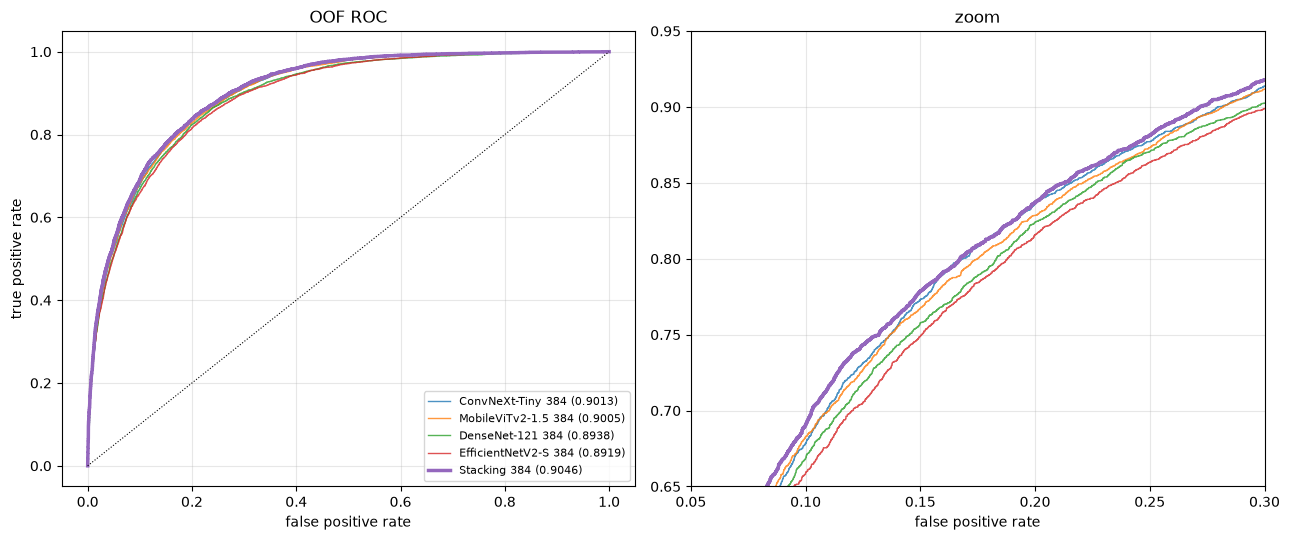

In [18]:
curves = {**{f"{NAMES[m]} 384": P384[:, i] for i, m in enumerate(TOP4)}, "Stacking 384": stacks["Stacking 384"]}
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for name, score in curves.items():
    fpr, tpr, _ = roc_curve(y, score)
    style = dict(lw=2.5) if name.startswith("Stacking") else dict(lw=1, alpha=0.8)
    for ax in axes:
        ax.plot(fpr, tpr, label=f"{name} ({roc_auc_score(y, score):.4f})", **style)
axes[0].plot([0, 1], [0, 1], "k:", lw=0.8)
axes[0].set(xlabel="false positive rate", ylabel="true positive rate", title="OOF ROC")
axes[1].set(xlim=(0.05, 0.3), ylim=(0.65, 0.95), xlabel="false positive rate", title="zoom")
for ax in axes:
    ax.grid(alpha=0.3)
axes[0].legend(loc="lower right", fontsize=8)
plt.tight_layout()

### 7.1 The chosen classifier

Stacking 384: its OOF scores (cross-validated) and its test scores (the combiner fitted on all OOF images, applied to the test scores of each fold's 4 models, and the 5 results averaged) are saved to `outputs/classification/stack_384/` for 06.

In [19]:
out_dir = CLS_DIR / "stack_384"
out_dir.mkdir(exist_ok=True)
T384 = np.stack([test_scores(384, m) for m in TOP4], axis=-1)  # (5 folds, images, 4 models)
pd.DataFrame({"patient_id": patients["patient_id"], "fold": fold, "class": patients["class"],
              "p_pneumonia": stacks["Stacking 384"]}).to_csv(out_dir / "oof_preds.csv", index=False)
pd.DataFrame({"patient_id": test["patient_id"], "p_pneumonia": np.mean([predict_lr(final, to_logit(t)) for t in T384], axis=0)}) \
    .to_csv(out_dir / "test_preds.csv", index=False)
print(sorted(p.name for p in out_dir.iterdir()))

['oof_preds.csv', 'test_preds.csv']


**Result**
- On the OOF images all 4 models are better at 384: +0.0018 to +0.0053 AUC. The intervals of ConvNeXt-Tiny and MobileViTv2 are above 0; those of DenseNet and EfficientNetV2-S touch 0.
- DenseNet's F1 at 0.5 drops (0.632 → 0.601) while its AUC rises: a threshold effect.
- **Stacking 384: OOF AUC 0.9046, F1 0.657**, +0.0028 over Stacking 256 (0.0017 to 0.0039).

### 7.2 Two augmentation checks

Two choices were not tested so far: the vertical flip (it turns the chest upside down, although opacities sit mostly in the middle and lower zones) and CLAHE, left open in 01. Fold 0, 384 × 384, one seed, otherwise the same training: ConvNeXt-Tiny and MobileViTv2-1.5 without the vertical flip, and ConvNeXt-Tiny on CLAHE images (clip limit 2, 8 × 8 tiles, applied at 1024 px before downscaling).

In [20]:
CHECKS = {"ConvNeXt-Tiny": ("convnext_tiny", ["main_384", "no_vflip_384", "clahe_384"]),
          "MobileViTv2-1.5": ("mobilevitv2_150", ["main_384", "no_vflip_384"])}
RUNS = {"main_384": "as in section 7", "no_vflip_384": "no vertical flip", "clahe_384": "CLAHE"}


def val0_run(experiment, model, tta):
    d = pd.read_csv(CLS_DIR / experiment / f"{model}_3c_f0_s0" / f"val_preds{'_tta' if tta else ''}.csv")
    assert (d["patient_id"].to_numpy() == ids0).all()
    return d["p_pneumonia"].to_numpy()


checks, rows = {}, []
for name, (m, experiments) in CHECKS.items():
    for e in experiments:
        a, b = checks[(name, e, False)], checks[(name, e, True)] = val0_run(e, m, False), val0_run(e, m, True)
        rows.append({"model": name, "run": RUNS[e], "AUC": roc_auc_score(y0, a), "F1": f1_score(y0, a >= 0.5),
                     "AUC + TTA": roc_auc_score(y0, b), "F1 + TTA": f1_score(y0, b >= 0.5)})
pd.DataFrame(rows).set_index(["model", "run"])

AUC     F1  AUC + TTA  F1 + TTA
model           run                                                
ConvNeXt-Tiny   as in section 7  0.9020 0.6217     0.9017    0.6272
                no vertical flip 0.9020 0.5973     0.9041    0.6089
                CLAHE            0.9006 0.6516     0.9014    0.6568
MobileViTv2-1.5 as in section 7  0.8996 0.6712     0.9021    0.6749
                no vertical flip 0.8985 0.6205     0.9004    0.6336

Paired bootstrap on the 5,337 fold-0 images, each run minus the run of section 7:

In [21]:
rows = [{"model": name, "run": RUNS[e], "TTA": "yes" if tta else "no",
         **paired_bootstrap(y0, checks[(name, e, tta)], checks[(name, "main_384", tta)])}
        for name, (m, experiments) in CHECKS.items() for e in experiments[1:] for tta in (False, True)]
pd.DataFrame(rows).set_index(["model", "run", "TTA"])

AUC difference       95% interval
model           run              TTA                                   
ConvNeXt-Tiny   no vertical flip no          -0.0000  [-0.0030, 0.0030]
                                 yes          0.0024  [-0.0004, 0.0052]
                CLAHE            no          -0.0014  [-0.0050, 0.0021]
                                 yes         -0.0003  [-0.0036, 0.0030]
MobileViTv2-1.5 no vertical flip no          -0.0010  [-0.0046, 0.0026]
                                 yes         -0.0017  [-0.0046, 0.0012]

**Result**
- **Without the vertical flip:** ConvNeXt-Tiny +0.0024 AUC with TTA, MobileViTv2 −0.0017; without TTA 0.0000 and −0.0010. Opposite signs and every interval includes 0: no measurable effect. **The vertical flip stays.**
- **CLAHE:** −0.0003 AUC with TTA (−0.004 to +0.003), no gain; its higher F1 at 0.5 is a threshold effect. **Not used.**

## 8. Copies of the same model: deep ensemble and bagging (fold 0)

Every run so far used one seed. Here we tried two ways of combining several copies of the same model:
- **Deep ensemble:** the same model trained several times on all training images, each time with a different random seed.
- **Bagging** (bootstrap aggregating): each copy is trained on its own bootstrap resample of the training images: as many images as the training set, drawn with replacement, so each copy sees about 63% of the distinct images, some of them several times. The variety comes from the data as well as the seed.

ConvNeXt-Tiny at 256 × 256, fold 0, the training of section 3; 5 copies each, seeds 0–4 (seed 0 on all images is the run of section 3). The copies are combined with the plain mean. Scores with TTA.

In [22]:
SEED0, SEEDS5, BAG5, STACK = "ConvNeXt-Tiny", "deep ensemble (5 seeds)", "bagging (5 models)", "stacking (4 models)"


def seed_run(seed, bootstrap=False):
    if seed == 0 and not bootstrap:
        return run_path(256, "convnext_tiny", 0)
    return CLS_DIR / "seeds_256" / f"convnext_tiny_3c_f0_s{seed}{'_boot' if bootstrap else ''}"


def seed_val0(run):
    d = pd.read_csv(run / "val_preds_tta.csv")
    assert (d["patient_id"].to_numpy() == ids0).all()
    return d["p_pneumonia"].to_numpy()


def score_row(p):
    return {"AUC + TTA": roc_auc_score(y0, p), "F1 + TTA": f1_score(y0, p >= 0.5)}


seeds = {s: seed_val0(seed_run(s)) for s in range(5)}
bags = {s: seed_val0(seed_run(s, bootstrap=True)) for s in range(5)}
copy_scores = {SEED0: seeds[0], SEEDS5: np.mean(list(seeds.values()), axis=0), BAG5: np.mean(list(bags.values()), axis=0)}

**Deep ensemble:** the 5 seeds and their mean:

In [23]:
deep = {f"seed {s}" + (" (section 3)" if s == 0 else ""): p for s, p in seeds.items()} | {SEEDS5: copy_scores[SEEDS5]}
pd.DataFrame({n: score_row(p) for n, p in deep.items()}).T.rename_axis("model")

,AUC + TTA,F1 + TTA
model,,
seed 0 (section 3),0.9011,0.6367
seed 1,0.8990,0.6000
seed 2,0.9003,0.6134
seed 3,0.8991,0.5970
seed 4,0.8982,0.5524
deep ensemble (5 seeds),0.9028,0.6099


**Bagging:** the 5 bagging models, the model trained on all images (seed 0) and the mean of the 5 bagging models:

In [24]:
rows = {"all images (seed 0)": {"distinct training images": config(256, "convnext_tiny")["n_train"], **score_row(seeds[0])}}
for s, p in bags.items():
    n_distinct = json.loads((seed_run(s, bootstrap=True) / "config.json").read_text())["n_train_unique"]
    rows[f"bagging model {s}"] = {"distinct training images": n_distinct, **score_row(p)}
rows[BAG5] = {"distinct training images": np.nan, **score_row(copy_scores[BAG5])}
table = pd.DataFrame(rows).T.astype({"distinct training images": "Int64"})
table["distinct training images"] = table["distinct training images"].astype(object).fillna("")
table.rename_axis("model")

,distinct training images,AUC + TTA,F1 + TTA
model,,,
all images (seed 0),21347,0.9011,0.6367
bagging model 0,13460,0.8968,0.6362
bagging model 1,13548,0.8912,0.6265
bagging model 2,13550,0.8936,0.5983
bagging model 3,13494,0.8960,0.6726
bagging model 4,13530,0.8986,0.5934
bagging (5 models),,0.9004,0.6474


**Comparison** with the stacking of the 4 different models at 256 × 256 (sections 5 and 7) on the same fold-0 images; its combiner for fold 0 was fitted on folds 1–4:

In [25]:
copy_scores = {STACK: stacks["Stacking 256"][fold == 0]} | copy_scores
pd.DataFrame({n: score_row(copy_scores[n]) for n in [STACK, SEED0, BAG5, SEEDS5]}).T.rename_axis("model")

,AUC + TTA,F1 + TTA
model,,
stacking (4 models),0.9038,0.6260
ConvNeXt-Tiny,0.9011,0.6367
bagging (5 models),0.9004,0.6474
deep ensemble (5 seeds),0.9028,0.6099


Paired bootstrap on the 5,337 fold-0 images:

In [26]:
bootstrap_table(y0, copy_scores, [(SEEDS5, SEED0), (BAG5, SEED0), (SEEDS5, BAG5), (STACK, SEED0), (STACK, SEEDS5)])

,AUC difference,95% interval
deep ensemble (5 seeds) − ConvNeXt-Tiny,0.0018,"[0.0001, 0.0033]"
bagging (5 models) − ConvNeXt-Tiny,-0.0007,"[-0.0031, 0.0017]"
deep ensemble (5 seeds) − bagging (5 models),0.0025,"[0.0006, 0.0044]"
stacking (4 models) − ConvNeXt-Tiny,0.0027,"[0.0007, 0.0046]"
stacking (4 models) − deep ensemble (5 seeds),0.0010,"[-0.0009, 0.0027]"


**Result**
- **Seed noise:** the seed alone moves the AUC between 0.8982 and 0.9011, and F1 at 0.5 between 0.55 and 0.64. Differences of ~0.002 between single fold-0 runs (sections 2, 4, 6, 7.2) are within this noise; this is why the decisions rest on bootstrap intervals and, where possible, on all 5 folds.
- **Deep ensemble:** the mean of the 5 seeds is better than one model, +0.0018 AUC (0.0001 to 0.0033). A real gain, but for 5× the training.
- **Bagging:** with ~63% of the distinct images, each bagging model is weaker than the model trained on all images (0.8912–0.8986 vs 0.9011), and the mean of the 5 does not make up for it (−0.0007, interval −0.0031 to +0.0017). It is worse than the deep ensemble (−0.0025, 0.0006 to 0.0044).
- **Stacking of 4 different models:** +0.0027 over one model (0.0007 to 0.0046) and +0.0010 over the deep ensemble (interval includes 0), for a similar cost (4 trainings instead of 5).
- **Choice: one seed per model, no bagging.** The 4-model stacking already gains at least as much as the seeds; adding seeds to each of its models would multiply the training by 5 (about 15 more GPU hours at 384), which we did not find worth it.

## 9. Summary

- **Classifier for 06:** 3 classes, stacking (logistic regression) of ConvNeXt-Tiny, MobileViTv2-1.5, DenseNet-121 and EfficientNetV2-S at 384 × 384 with flip TTA. OOF AUC 0.9046, F1 0.657 at 0.5.
- From the best single model at 256 (0.8976): the ensemble adds ~0.004 AUC, the higher resolution ~0.003.
- Did not help: a larger backbone (ConvNeXt V2-Base), metadata (view, sex, age), 512 × 512, more than 4 models, CLAHE, dropping the vertical flip, bagging. Extra seeds of the same model (deep ensemble) gained too little for the cost (+0.0018 AUC for 5× the training).
- The threshold (and how the classifier gates the detector) is chosen in 06 with the competition metric.
- Limits: one seed per run, and a single model's fold-0 AUC moves by up to 0.003 with the seed alone (section 8); the bootstrap intervals cover the choice of images only, not this seed noise or picking the best epoch on the validation fold. The decisions made on fold 0 alone (3 classes, V2-Base, 512, the augmentation checks) rest on 5,337 images.